# Variable selection

## Loading the data

In [31]:
import numpy as np

kiwi_spectra = np.loadtxt("results/kiwi_avg_spectra.csv", delimiter=",")
reference_values = np.loadtxt("data/reference.csv", delimiter=",")
wl = np.loadtxt("results/wavelengths.csv", delimiter=",")
reference_values = reference_values[:180, 0]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
 
from scipy.signal import savgol_filter
 
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

X = kiwi_spectra
y = reference_values
 
# Calculate derivatives
X1 = savgol_filter(X, 11, polyorder = 2, deriv=1)
X2 = savgol_filter(X, 13, polyorder = 2,deriv=2)

(180, 224)


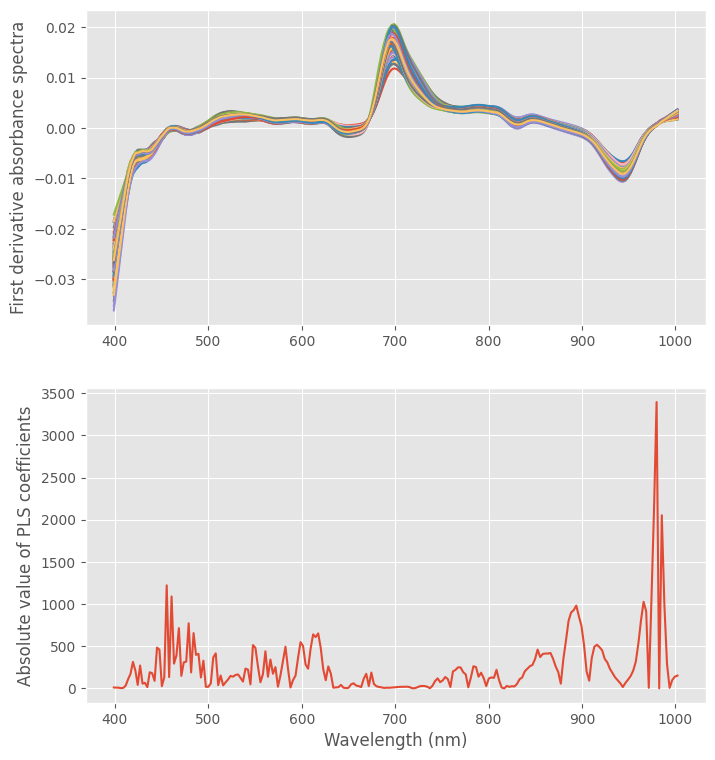

In [33]:
# Define the PLS regression object
pls = PLSRegression(n_components=14)
# Fit data
pls.fit(X1, y)

print(X1.shape)
 
# Plot spectra
plt.figure(figsize=(8,9))
with plt.style.context(('ggplot')):
    ax1 = plt.subplot(211)
    plt.plot(wl, X1.T)
    plt.ylabel('First derivative absorbance spectra')
 
    ax2 = plt.subplot(212, sharex=ax1)
    plt.plot(wl, np.abs(pls.coef_.T))
    plt.xlabel('Wavelength (nm)')
    plt.ylabel('Absolute value of PLS coefficients')
 
    plt.show()

In [49]:
def pls_variable_selection(X, y, max_comp):
    
    # Define MSE array to be populated
    mse = np.zeros((max_comp,X.shape[1]))
 
    # Loop over the number of PLS components
    for i in range(max_comp):
        
        # Regression with specified number of components, using full spectrum
        pls1 = PLSRegression(n_components=i+1)
        pls1.fit(X, y)
        
        # Indices of sort spectra according to ascending absolute value of PLS coefficients
        sorted_ind = np.argsort(np.abs(pls1.coef_))
 
        # Sort spectra accordingly 
        Xc = X[:,sorted_ind]
 
        # Discard one wavelength at a time of the sorted spectra,
        # regress, and calculate the MSE cross-validation
        for j in range(Xc.shape[2]-(i+1)):
 
            pls2 = PLSRegression(n_components=i+1)
            pls2.fit(Xc[:, 0, j:], y)
            
            y_cv = cross_val_predict(pls2, Xc[:, 0, j:], y, cv=5)
 
            mse[i,j] = mean_squared_error(y, y_cv)
            print(f"Checked {i} components with {j} wavelengths removal")

    # Replace with your actual matrix
    masked = np.where(mse == 0, np.nan, mse)    
    min_val = np.nanmin(masked)
    min_pos = np.unravel_index(np.nanargmin(masked), mse.shape)
    print("Minimum non-zero value:", min_val)
    print("Position:", min_pos)

    mseminx, mseminy = min_pos

    print("Optimised number of PLS components: ", mseminx+1)
    print("Wavelengths to be discarded ",mseminy)
    print('Optimised MSEP ', mse[mseminx,mseminy])

    # Calculate PLS with optimal components and export values
    pls = PLSRegression(n_components=mseminx+1)
    pls.fit(X, y)
        
    sorted_ind = np.argsort(np.abs(pls.coef_))

    Xc = X[:,sorted_ind]

    return Xc[:, 0, mseminy:],mseminx+1,mseminy, sorted_ind

In [ ]:
best_X,n_components, n_wavelenghs_removed, sorted_ind = pls_variable_selection(X, y, max_comp=30)

Checked 0 components with 0 wavelengths removal
Checked 0 components with 1 wavelengths removal
Checked 0 components with 2 wavelengths removal
Checked 0 components with 3 wavelengths removal
Checked 0 components with 4 wavelengths removal
Checked 0 components with 5 wavelengths removal
Checked 0 components with 6 wavelengths removal
Checked 0 components with 7 wavelengths removal
Checked 0 components with 8 wavelengths removal
Checked 0 components with 9 wavelengths removal
Checked 0 components with 10 wavelengths removal
Checked 0 components with 11 wavelengths removal
Checked 0 components with 12 wavelengths removal
Checked 0 components with 13 wavelengths removal
Checked 0 components with 14 wavelengths removal
Checked 0 components with 15 wavelengths removal
Checked 0 components with 16 wavelengths removal
Checked 0 components with 17 wavelengths removal
Checked 0 components with 18 wavelengths removal
Checked 0 components with 19 wavelengths removal
Checked 0 components with 20 w

In [56]:

def simple_pls_cv(X, y, n_comp):
 
    # Run PLS with suggested number of components
    pls = PLSRegression(n_components=n_comp)
    pls.fit(X, y)
    y_c = pls.predict(X)
    
    pls = PLSRegression(n_components=n_comp)
    # Cross-validation
    y_cv = cross_val_predict(pls, X, y, cv=10)    
 
    # Calculate scores for calibration and cross-validation
    score_c = r2_score(y, y_c)
    score_cv = r2_score(y, y_cv)
 
    # Calculate mean square error for calibration and cross validation
    mse_c = mean_squared_error(y, y_c)
    mse_cv = mean_squared_error(y, y_cv)
 
    print('R2 calib: %5.3f'  % score_c)
    print('R2 CV: %5.3f'  % score_cv)
    print('RMSE calib: %5.3f' % np.sqrt(mse_c))
    print('RMSE CV: %5.3f' % np.sqrt(mse_cv))
 
    # Plot regression 
 
    z = np.polyfit(y, y_cv, 1)
    with plt.style.context(('ggplot')):
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.scatter(y_cv, y, c='red', edgecolors='k')
        ax.plot(z[1]+z[0]*y, y, c='blue', linewidth=1)
        ax.plot(y, y, color='green', linewidth=1)
        plt.title('$R^{2}$ (CV): '+str(score_cv))
        plt.xlabel('Predicted Dry Matter')
        plt.ylabel('Measured Dry Matter')
        
        plt.show()

R2 calib: 0.931
R2 CV: 0.833
RMSE calib: 0.496
RMSE CV: 0.772


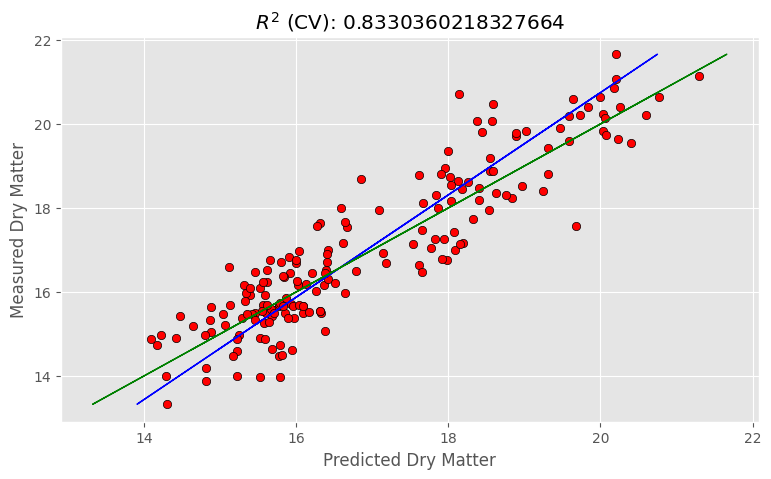

In [57]:
simple_pls_cv(X, y, n_components)

R2 calib: 0.936
R2 CV: 0.879
RMSE calib: 0.477
RMSE CV: 0.658


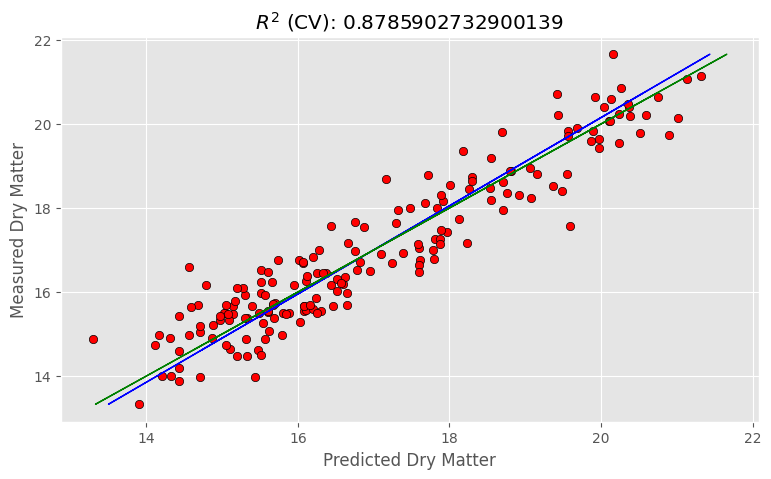

In [58]:
simple_pls_cv(best_X, y, n_components)

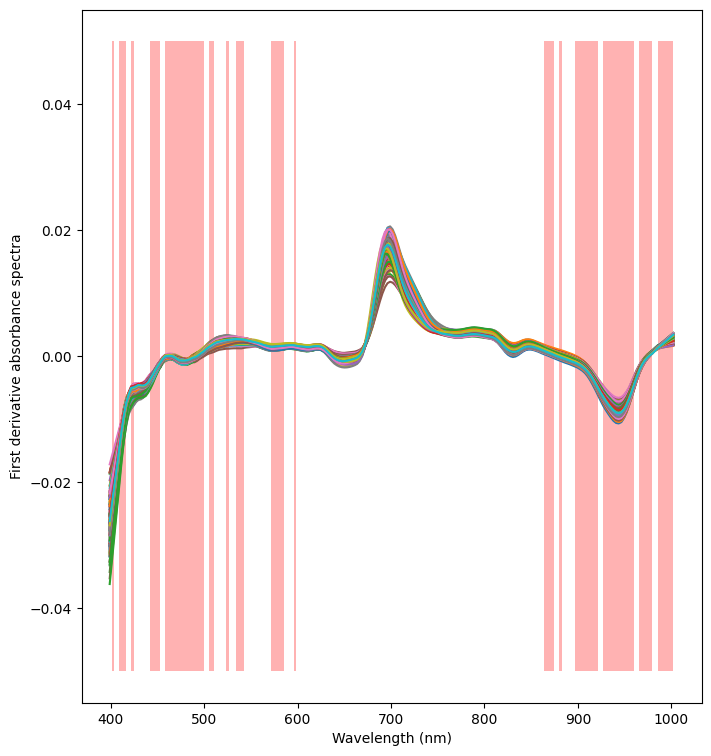

In [71]:
# Get indices of wavelengths to remove
removed_inds = sorted_ind[0,:n_wavelenghs_removed]

# Create boolean mask (False = removed, True = kept)
ix = np.ones(wl.shape[0], dtype=bool)
ix[removed_inds] = False
 
# Plot spectra with superimpose selected bands
fig, ax = plt.subplots(figsize=(8,9))
with plt.style.context(('ggplot')):
    ax.plot(wl, X1.T)
    plt.ylabel('First derivative absorbance spectra')
    plt.xlabel('Wavelength (nm)')

ax.fill_between(wl, y1=-0.05, y2=0.05, where=ix == True, facecolor='red', alpha=0.3) 
plt.show()

In [3]:
import numpy as np

kiwi_spectra = np.loadtxt("results/kiwi_avg_spectra.csv", delimiter=",")
reference_values = np.loadtxt("data/reference.csv", delimiter=",")
wl = np.loadtxt("results/wavelengths.csv", delimiter=",")
reference_values = reference_values[:180, 0]

In [4]:
import numpy as np
import matplotlib.pyplot as plt
 
from scipy.signal import savgol_filter
 
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score

X = kiwi_spectra
y = reference_values
 
# # Calculate derivatives
# X1 = savgol_filter(X, 11, polyorder = 2, deriv=1)
# X2 = savgol_filter(X, 13, polyorder = 2,deriv=2)

# Kennard stone partition data

## Variable selection (COVSCL)

## Predictive model based on selected variables